# E-OBS SPI-1 calculation

Computes Standardized Precipitation Index (SPI-1) from E-OBS daily precipitation.
Uses RR data on 0.25° grid; Eastern Norway subset (60.5–62.5°N, 9.5–11.5°E).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import scipy.stats as stats
import eobs
import copy
from matplotlib.colors import ListedColormap


# Preprocess

In [64]:
def display_netcdf_minimal(xarray):
    temp = copy.deepcopy(xarray)
    temp.attrs = {}
    display(temp)

# Define Region

In [ ]:
# Eastern Norway bounds (from ECMWF)
lat_min = 60.5
lat_max = 62.5
lon_min = 9.5
lon_max = 11.5

# Load Data

In [66]:
dataset = eobs.load_netcdf_as_xarray(
    filename='rr_ens_mean_0.25deg_reg_v30.0e.nc',
    directory='data.nosync/eobs.nosync')

Loaded dataset from data.nosync/eobs.nosync/rr_ens_mean_0.25deg_reg_v30.0e.nc


In [67]:
display_netcdf_minimal(dataset)

<xarray.Dataset> Size: 10GB
Dimensions:    (time: 27210, latitude: 201, longitude: 464)
Coordinates:
  * latitude   (latitude) float64 2kB 25.38 25.62 25.88 ... 74.88 75.12 75.38
  * longitude  (longitude) float64 4kB -40.38 -40.12 -39.88 ... 75.12 75.38
  * time       (time) datetime64[ns] 218kB 1950-01-01 1950-01-02 ... 2024-06-30
Data variables:
    rr         (time, latitude, longitude) float32 10GB ...

In [68]:
eobs.print_characteristics(dataset, 'rr')

Time dimension size: (27210,)
Time granularity: 1 day
Time period: from 1950-01-01 to 2024-06-30

Longitude dimension size: (464,)
Latitude dimension size: (201,)

Precipitation dimensions: ('time', 'latitude', 'longitude')
Precipitation dimension size: (27210, 201, 464)
Precipitation unit: daily precipitation sum

Latitude min/max: 25.375 / 75.375
Longitude min/max: -40.375 / 75.375


# Eastern Norway subset

In [ ]:
dataset_eastnor = dataset.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)
dataset_eastnor

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 27210, latitude: 8, longitude: 8)
Coordinates:
  * latitude   (latitude) float64 64B 60.62 60.88 61.12 ... 61.88 62.12 62.38
  * longitude  (longitude) float64 64B 9.625 9.875 10.12 ... 10.88 11.12 11.38
  * time       (time) datetime64[ns] 218kB 1950-01-01 1950-01-02 ... 2024-06-30
Data variables:
    rr         (time, latitude, longitude) float32 7MB ...
Attributes:
    E-OBS_version:  30.0e
    Conventions:    CF-1.4
    References:     http://surfobs.climate.copernicus.eu/dataaccess/access_eo...
    history:        Fri Aug 30 12:51:50 2024: ncks --no-abc -d time,0,27209 /...
    NCO:            netCDF Operators version 5.1.8 (Homepage = http://nco.sf....

In [47]:
del dataset

In [48]:
print(f"Eastern Norway subset:")
print(f"  Latitude range: {dataset_eastnor.latitude.values.min():.2f} to {dataset_eastnor.latitude.values.max():.2f}")
print(f"  Longitude range: {dataset_eastnor.longitude.values.min():.2f} to {dataset_eastnor.longitude.values.max():.2f}")
print(f"  Time range: {dataset_eastnor.time.values[0]} to {dataset_eastnor.time.values[-1]}")
print(f"  Shape: {dataset_eastnor.dims}")

Eastern Norway subset:
  Latitude range: 60.62 to 62.38
  Longitude range: 9.62 to 11.38
  Time range: 1950-01-01T00:00:00.000000000 to 2024-06-30T00:00:00.000000000
  Shape: FrozenMappingWarningOnValuesAccess({'time': 27210, 'latitude': 8, 'longitude': 8})


# NaN analysis
We have data for 1) all days and 2) across all locations

In [49]:
vals = dataset_eastnor['rr'].values
n_timesteps = vals.shape[0]
nan_count = np.isnan(vals).sum(axis=0)
tl = nan_count.size
no_nan = (nan_count == 0).sum()
all_nan = (nan_count == n_timesteps).sum()
partial_nan = ((nan_count > 0) & (nan_count < n_timesteps)).sum()
print(f"\n[rr] 100% Valid: {no_nan} ({no_nan/tl*100:.1f}%) | 100% NaN: {all_nan} ({all_nan/tl*100:.1f}%) | Partial NaN: {partial_nan} ({partial_nan/tl*100:.1f}%) | {'✓ CLEAN' if partial_nan==0 else '⚠ MIXED'}")


[rr] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN


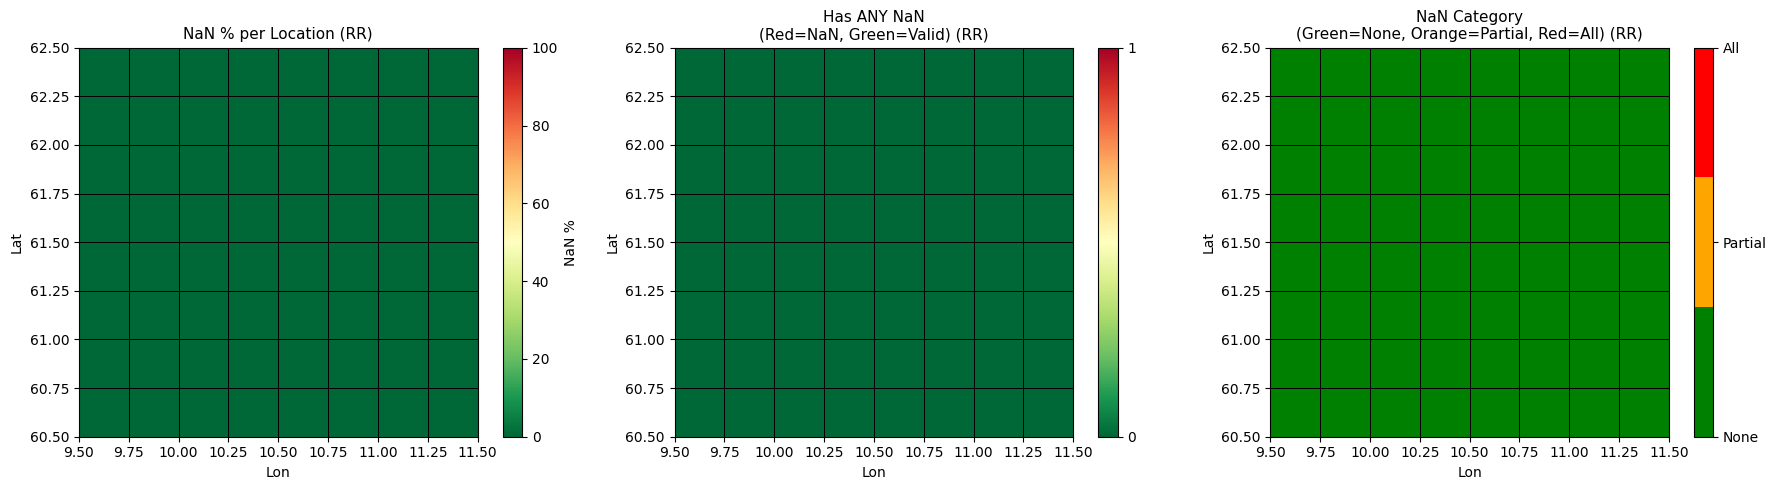

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = [
    'NaN % per Location', 
    'Has ANY NaN\n(Red=NaN, Green=Valid)',
    'NaN Category\n(Green=None, Orange=Partial, Red=All)'
]

vals = dataset_eastnor['rr'].values
n_timesteps = vals.shape[0]
nan_count = np.isnan(vals).sum(axis=0)
lat = dataset_eastnor.latitude.values
lon = dataset_eastnor.longitude.values
lon_grid, lat_grid = np.meshgrid(lon, lat)

# Plot 1: NaN %
im1 = axes[0].pcolormesh(lon_grid, lat_grid, (nan_count / n_timesteps) * 100, cmap='RdYlGn_r', vmin=0, vmax=100, edgecolors='k', linewidth=0.5)
axes[0].set_title(f'{titles[0]} (RR)', fontsize=11)
axes[0].set_xlabel('Lon'); axes[0].set_ylabel('Lat')
plt.colorbar(im1, ax=axes[0], label='NaN %')

# Plot 2: Binary
has_any_nan = (nan_count > 0).astype(int)
im2 = axes[1].pcolormesh(lon_grid, lat_grid, has_any_nan, cmap='RdYlGn_r', vmin=0, vmax=1, edgecolors='k', linewidth=0.5)
axes[1].set_title(f'{titles[1]} (RR)', fontsize=11)
axes[1].set_xlabel('Lon'); axes[1].set_ylabel('Lat')
plt.colorbar(im2, ax=axes[1], ticks=[0,1])

# Plot 3: Ternary
nan_cat = np.zeros_like(nan_count, dtype=int)
nan_cat[nan_count == 0] = 0
nan_cat[(nan_count > 0) & (nan_count < n_timesteps)] = 1
nan_cat[nan_count == n_timesteps] = 2
im3 = axes[2].pcolormesh(lon_grid, lat_grid, nan_cat, cmap=ListedColormap(['green', 'orange', 'red']), vmin=0, vmax=2, edgecolors='k', linewidth=0.5)
axes[2].set_title(f'{titles[2]} (RR)', fontsize=11)
axes[2].set_xlabel('Lon'); axes[2].set_ylabel('Lat')
cbar = plt.colorbar(im3, ax=axes[2], ticks=[0,1,2])
cbar.ax.set_yticklabels(['None', 'Partial', 'All'])

plt.tight_layout(); plt.show()

# Average Over Lat Lon

In [ ]:
dataset_eastnor_avgloc = dataset_eastnor.mean(dim=['latitude', 'longitude'])
dataset_eastnor_avgloc

✓ Spatial aggregation complete
  Shape: FrozenMappingWarningOnValuesAccess({'time': 27210})


<xarray.Dataset> Size: 327kB
Dimensions:  (time: 27210)
Coordinates:
  * time     (time) datetime64[ns] 218kB 1950-01-01 1950-01-02 ... 2024-06-30
Data variables:
    rr       (time) float32 109kB 4.459 1.07 2.278 1.638 ... 4.206 5.461 0.0 0.0

# Sum Over Month

In [ ]:
dataset_eastnor_avgloc_avgmonthly = dataset_eastnor_avgloc.resample(time='1M').sum(skipna=True)
dataset_eastnor_avgloc_avgmonthly

/usr/local/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


✓ Monthly resampling complete
  Shape: FrozenMappingWarningOnValuesAccess({'time': 894})


<xarray.Dataset> Size: 11kB
Dimensions:  (time: 894)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-31 1950-02-28 ... 2024-06-30
Data variables:
    rr       (time) float32 4kB 42.44 42.41 13.23 51.4 ... 34.87 28.91 104.2

# Reshape to year times month

In [ ]:
dataset_eastnor_avgloc_avgmonthly_year_month = eobs.rr_change_date_format_from_1D_to_2D(
    dataset_eastnor_avgloc_avgmonthly, verbose=False
)
dataset_eastnor_avgloc_avgmonthly_year_month_verbatim = dataset_eastnor_avgloc_avgmonthly_year_month.assign_coords(
    month=['January', 'February', 'March', 'April', 'May', 'June', 'July', 
           'August', 'September', 'October', 'November', 'December']
)
dataset_eastnor_avgloc_avgmonthly_year_month_verbatim

✓ Date format transformation complete
  Shape: FrozenMappingWarningOnValuesAccess({'year': 75, 'month': 12})


<xarray.Dataset> Size: 8kB
Dimensions:  (year: 75, month: 12)
Coordinates:
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
  * month    (month) <U9 432B 'January' 'February' ... 'November' 'December'
Data variables:
    rr       (year, month) float64 7kB 42.44 42.41 13.23 51.4 ... nan nan nan

# SPI-1 calculation

## Create SPI-1 Data Structures

In [ ]:
dataset = dataset_eastnor_avgloc_avgmonthly_year_month_verbatim

spi_1_values_array = xr.DataArray(
    data=np.nan,  # Initialize with NaNs
    dims=["year", "month"],
    coords={
        "year": copy.deepcopy(dataset.year.values),
        "month": copy.deepcopy(dataset.month.values),
    }
)

spi_1_datastructure = xr.Dataset({"spi_1_values": spi_1_values_array})

gamma_params_array = xr.DataArray(
    data=np.nan,  # Initialize with NaNs
    dims=["year", "month", "gamma_parameters"],
    coords={
        "year": copy.deepcopy(dataset.year.values),
        "month": copy.deepcopy(dataset.month.values),
        "gamma_parameters": ["shape", "loc", "scale"],
    }
)

gamma_parameters_datastructure = xr.Dataset({"gamma_values": gamma_params_array})
spi_1_datastructure

✓ SPI-1 data structures created
  SPI values shape: FrozenMappingWarningOnValuesAccess({'year': 75, 'month': 12})
  Gamma parameters shape: FrozenMappingWarningOnValuesAccess({'year': 75, 'month': 12, 'gamma_parameters': 3})


<xarray.Dataset> Size: 8kB
Dimensions:       (year: 75, month: 12)
Coordinates:
  * year          (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
  * month         (month) <U9 432B 'January' 'February' ... 'December'
Data variables:
    spi_1_values  (year, month) float64 7kB nan nan nan nan ... nan nan nan nan

## Compute SPI-1
We do not handle 0s correctly in this implementation (as we do in the FENNO_ version). However, there are 0 months with 0 precipitation, so it's no need to do it.

In [ ]:
dataset = dataset_eastnor_avgloc_avgmonthly_year_month_verbatim
rr_values = dataset['rr'].values
n_zeros = (rr_values == 0).sum()
n_negs = (rr_values < 0).sum()
n_total = rr_values.size
pct_zeros = (n_zeros / n_total) * 100
pct_negs = (n_negs / n_total) * 100

print(f"Zero precipitation months: {n_zeros} out of {n_total} ({pct_zeros:.2f}%)")
print(f"Negative precipitation months: {n_negs} out of {n_total} ({pct_negs:.4f}%)")

Zero precipitation months: 0 out of 900 (0.00%)
Negative precipitation months: 0 out of 900 (0.0000%)
✓ No zeros found - current implementation is fine
✓ No negative precipitation values found


In [ ]:
dataset = dataset_eastnor_avgloc_avgmonthly_year_month_verbatim
all_months = dataset.month.values
all_years = dataset.year.values

for month in all_months:
    dataset_given_month = dataset.sel(month=month)
    
    for i, year in enumerate(all_years):
        # Exclude the current year from the dataset (leave-one-out)
        dataset_xa_given_month_wout_year = dataset_given_month.sel(
            year=~dataset_given_month.year.isin([year])
        )
        
        # Get precipitation data
        test_data = np.array(dataset_given_month['rr'])  # All years including current
        distribution_data = np.array(dataset_xa_given_month_wout_year['rr'])  # All years except current
        
        # Filter out NaN values before fitting gamma distribution
        distribution_data = distribution_data[~np.isnan(distribution_data)]
        
        if len(distribution_data) > 0:  # Ensure there is valid data to fit
            # Fit gamma distribution to positive values (floc=0 forces loc parameter to 0)
            shape, loc, scale = stats.gamma.fit(distribution_data, floc=0)
            
            # Store gamma parameters
            gamma_parameters_datastructure['gamma_values'].loc[year, month, 'shape'] = float(shape)
            gamma_parameters_datastructure['gamma_values'].loc[year, month, 'loc'] = float(loc)
            gamma_parameters_datastructure['gamma_values'].loc[year, month, 'scale'] = float(scale)
            
            # Calculate gamma CDF for current year's precipitation
            gamma_cdf = stats.gamma.cdf(test_data, a=shape, scale=scale, loc=loc)
            
            # Convert gamma CDF to SPI values using normal distribution inverse CDF
            spi_values = stats.norm.ppf(gamma_cdf)
            
            # Get the SPI value for the current year (index i in test_data)
            spi_value = spi_values[i]
            
            # Store the SPI value
            spi_1_datastructure['spi_1_values'].loc[year, month] = float(spi_value)

eobs_eastnor_spi_1_values = spi_1_datastructure
eobs_eastnor_spi_1_gamma_parameters = gamma_parameters_datastructure

eobs_eastnor_spi_1_values

Calculating SPI-1 values...
Processing 12 months × 75 years = 900 values

✓ SPI-1 calculation complete!


<xarray.Dataset> Size: 8kB
Dimensions:       (year: 75, month: 12)
Coordinates:
  * year          (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
  * month         (month) <U9 432B 'January' 'February' ... 'December'
Data variables:
    spi_1_values  (year, month) float64 7kB 0.2185 0.8608 -0.9664 ... nan nan

# Check NaN values (still July to December 2024 only?)

In [ ]:
n_nan_2d = np.isnan(eobs_eastnor_spi_1_values["spi_1_values"].values).sum()
n_total_2d = np.prod(eobs_eastnor_spi_1_values["spi_1_values"].values.shape)

print(f"NaN values in 2D year-month SPI-1 array: {n_nan_2d} of {n_total_2d}")

# Now, find out how many NaNs are present in the period July-December 2024, in the 2D array
years = eobs_eastnor_spi_1_values.year.values
months = eobs_eastnor_spi_1_values.month.values

if months.dtype.kind in "iu":
    months_jul_dec = [7,8,9,10,11,12]
else:
    months_jul_dec = ['July', 'August', 'September', 'October', 'November', 'December']

try:
    idx_2024 = np.where(years == 2024)[0][0]
    idx_months = [np.where(months == m)[0][0] for m in months_jul_dec]
    n_nan_jul2dec2024 = np.isnan(eobs_eastnor_spi_1_values["spi_1_values"].values[idx_2024, idx_months]).sum()
except Exception as e:
    print("Error extracting NaNs for July-Dec 2024:", e)
    n_nan_jul2dec2024 = 0

if n_nan_2d > 0:
    pct_juldec_of_nans = 100.0 * n_nan_jul2dec2024 / n_nan_2d
    print(f"{pct_juldec_of_nans:.1f}% of NaNs from July-Dec 2024.")

NaN values in 2D year-month SPI-1 array: 6 of 900
NaN values from July-Dec 2024: 6
100.0% of NaNs from July-Dec 2024.
All NaN values in the SPI-1 dataset are from July-December 2024.


# Validate Results

In [ ]:
mean_spi = eobs_eastnor_spi_1_values.mean(dim='year')
sd_spi = eobs_eastnor_spi_1_values.std(dim='year')
mean_spi = mean_spi.to_dataframe().reset_index()
sd_spi = sd_spi.to_dataframe().reset_index()

mean_sd_spi = pd.merge(mean_spi, sd_spi, on=['month'], suffixes=('_mean', '_sd'))
mean_sd_spi

,month,spi_1_values_mean,spi_1_values_sd
0,January,0.000133,1.031940
1,February,0.000924,1.034544
2,March,0.005536,1.055052
3,April,0.002574,1.034369
4,May,0.001052,1.028027
5,June,0.000109,1.037837
6,July,-0.000691,1.027538
7,August,-0.000113,1.030057
8,September,-0.001116,1.027253
9,October,-0.000268,1.025730


In [3]:
# Do the same SPI mean/SD calculation for 1993 onward

# Load and select data from 1993 to the end
eobs_eastnor_spi_1_values_post_1993 = eobs_eastnor_spi_1_values.sel(year=slice(1993, None))

# Calculate mean and SD for each month for 1993+
mean_spi_post_1993 = eobs_eastnor_spi_1_values_post_1993.mean(dim='year')
sd_spi_post_1993 = eobs_eastnor_spi_1_values_post_1993.std(dim='year')

mean_spi_post_1993_df = mean_spi_post_1993.to_dataframe().reset_index()
sd_spi_post_1993_df = sd_spi_post_1993.to_dataframe().reset_index()

mean_sd_spi_post_1993 = pd.merge(
    mean_spi_post_1993_df, 
    sd_spi_post_1993_df, 
    on=['month'], 
    suffixes=('_mean', '_sd')
)

print("\nMean and SD of SPI by month (1993 and later):")
print(mean_sd_spi_post_1993[['month', 'spi_1_values_mean', 'spi_1_values_sd']])

# Calculate averages across all months for 1993+
avg_mean_spi_post_1993 = mean_sd_spi_post_1993['spi_1_values_mean'].mean()
avg_sd_spi_post_1993 = mean_sd_spi_post_1993['spi_1_values_sd'].mean()

print(f"\nAverage mean SPI (1993+) across all months: {avg_mean_spi_post_1993:.5f}")
print(f"Average SD SPI (1993+) across all months: {avg_sd_spi_post_1993:.5f}")



Mean and SD of SPI by month (1993 and later):
        month  spi_1_values_mean  spi_1_values_sd
0     January           0.347205         0.909173
1    February           0.314255         0.770740
2       March           0.068734         0.946984
3       April           0.130935         1.031799
4         May           0.242935         1.037238
5        June           0.171469         0.770789
6        July           0.019493         1.049051
7      August           0.193499         0.948994
8   September          -0.138130         0.986325
9     October           0.089363         1.002849
10   November           0.017161         1.162532
11   December           0.048685         0.952754

Average mean SPI (1993+) across all months: 0.12547
Average SD SPI (1993+) across all months: 0.96410


# SPI-1 Values Per Month

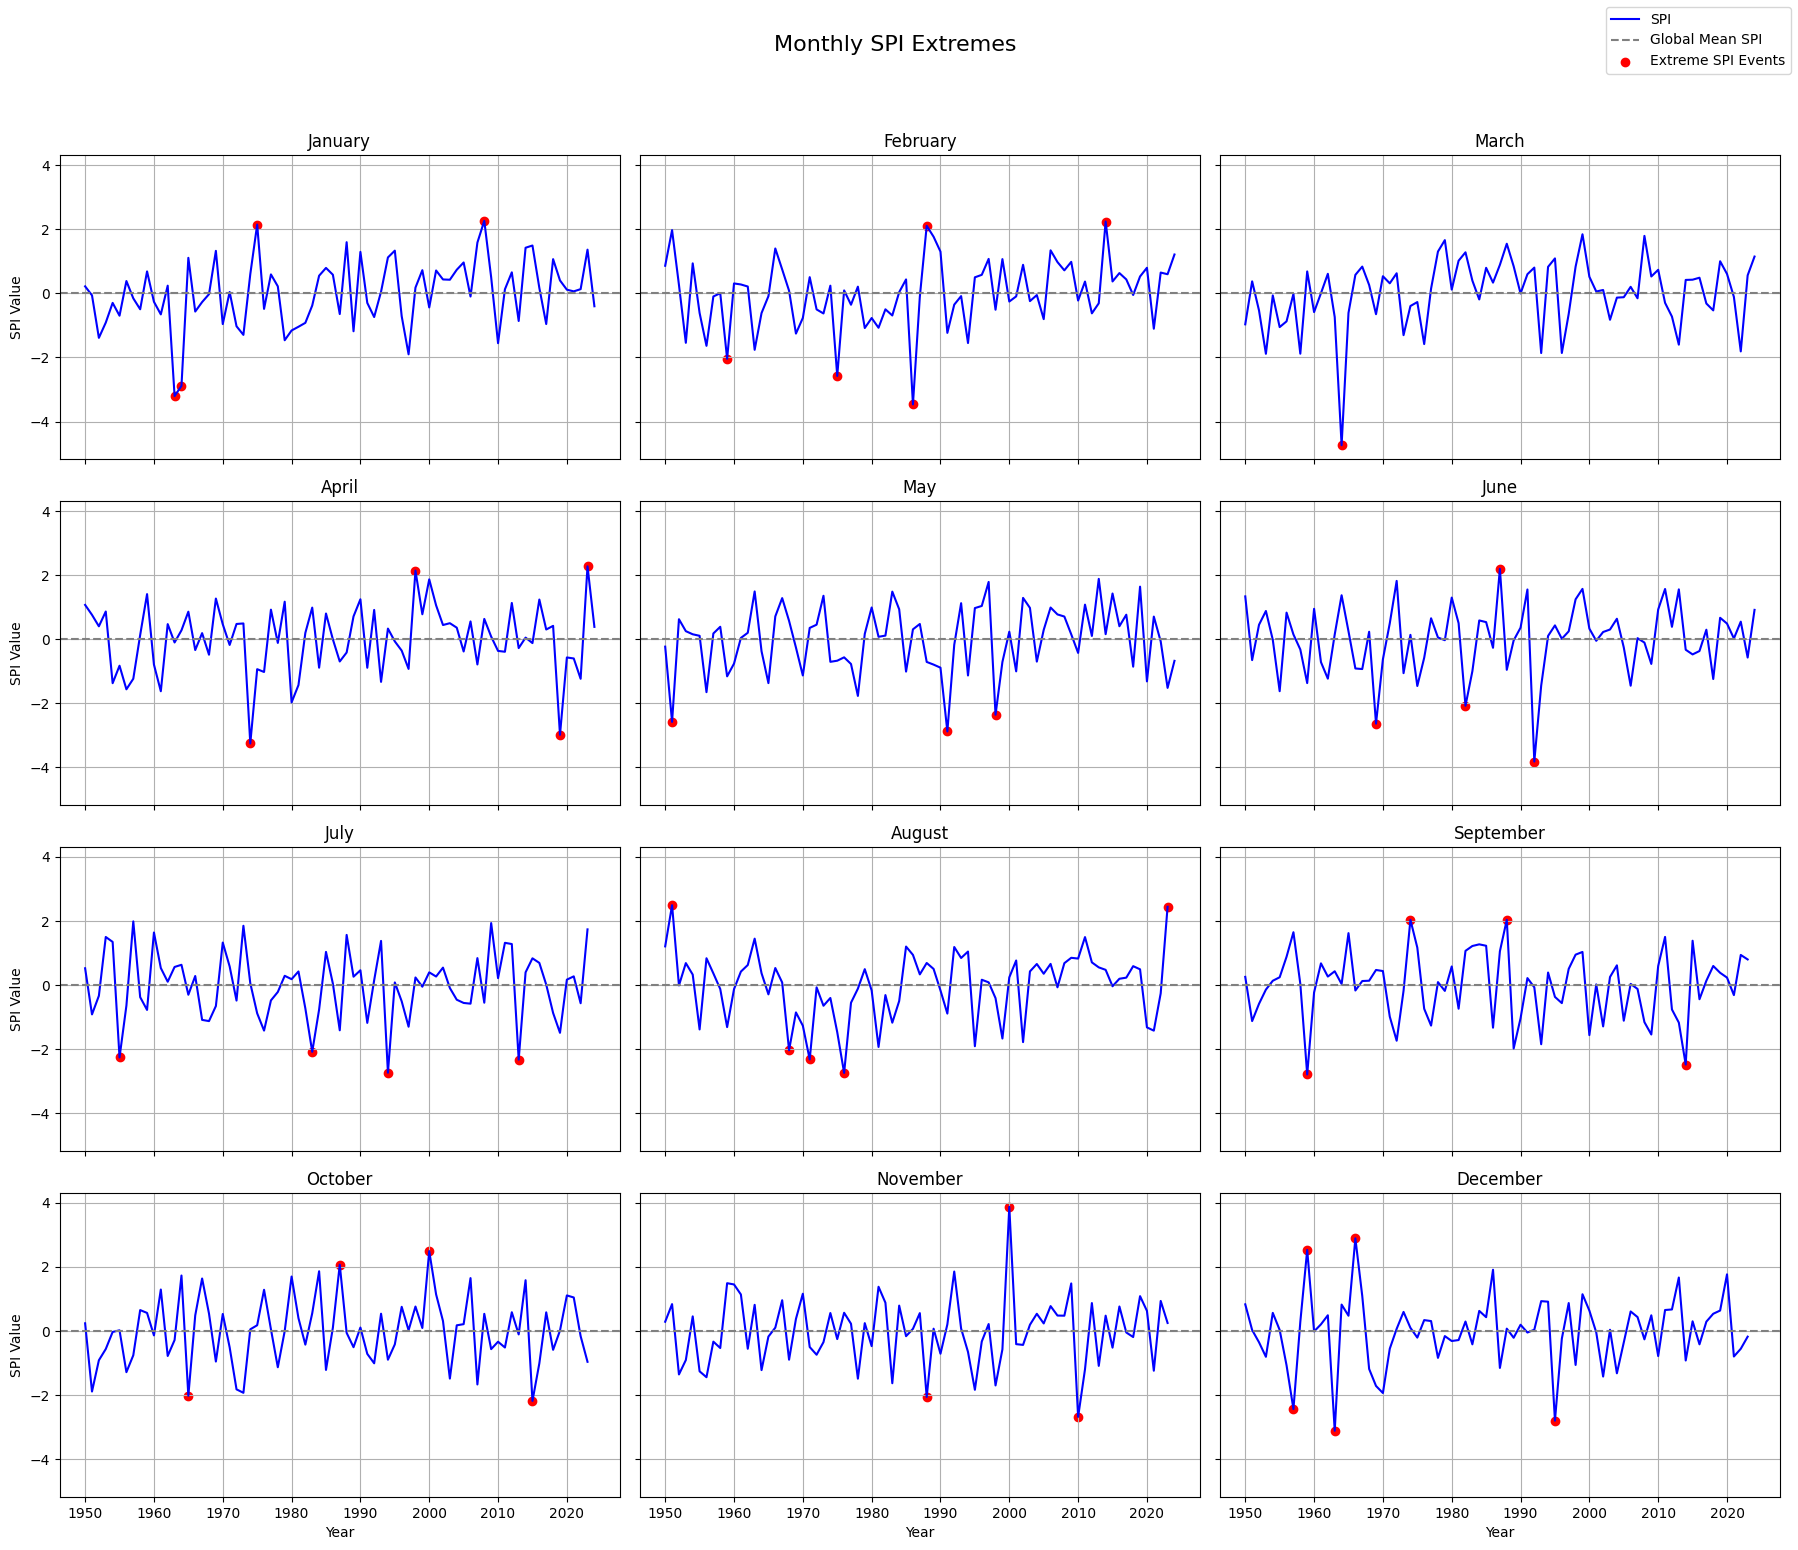

In [ ]:
spi_values = eobs_eastnor_spi_1_values['spi_1_values']

# Calculate the global mean SPI for each month
monthly_mean_spi = spi_values.mean(dim='year')

# Prepare for plotting
fig, axes = plt.subplots(4, 3, figsize=(18, 16), sharex=True, sharey=True)  # Adjusted to 4 rows, 3 columns
fig.suptitle('Monthly SPI Extremes', fontsize=16)

extreme_threshold_upper = 2
extreme_threshold_lower = -2

months = spi_values.month.values
for i, month in enumerate(months):
    ax = axes.flatten()[i]
    month_index = spi_values.sel(month=month)
    ax.plot(spi_values.year, month_index, label='SPI', color='blue')

    ax.axhline(monthly_mean_spi.sel(month=month), color='gray', linestyle='--', label='Global Mean SPI')
    extreme_events = month_index.where((month_index > extreme_threshold_upper) | (month_index < extreme_threshold_lower), drop=True)
    ax.scatter(extreme_events.year, extreme_events, color='red', label='Extreme SPI Events')

    ax.set_title(month.capitalize())
    ax.grid(True)

    # Adjust label settings for the new subplot dimensions
    if i % 3 == 0:  # Adjusted for 3 columns
        ax.set_ylabel('SPI Value')
    if i >= 9:  # Adjusted for the bottom row of 4x3 layout
        ax.set_xlabel('Year')

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.show()